# Make Climatology for Input and Target Times

Climatology is made for the years 1979-2015 (years GraphCast_small was trained with)

In [1]:
import xarray as xr

from pkg.mask.download_mask_data import download_era5_for_climatology_with_unzipping
from pkg.mask.climatology import compute_era5_climatology
from pkg.plots.plot_variable import plot_variable

In [2]:
climatology_folder = "../data/data_for_climatology/era5_climatology/"
output_path = "../data/data_for_climatology/era5_1979-2015_0218_climatology.nc"

## Download and Compute Climatology

In [ ]:
# data for graphcast_small on the 18th of February 10:00, 16:00 and 22:00 UTC (1979-2015)

download_era5_for_climatology_with_unzipping(
    years=range(1979, 2016),
    month=2, day=18,
    times=["10:00", "16:00", "22:00"],
    levels=13,
    grid=1.0,
    out_dir=climatology_folder,
    upload_to_gcs=False
)


In [ ]:
# calculate and save average climatology 

clim = compute_era5_climatology(
    input_folder=climatology_folder,
    output_path=output_path,
    upload_to_gcs=False
)

## Show Climatology for Desired Feature

In [ ]:
# input data for zeynep as comparison
input_zeynep_path = "../data/graphcast_small/graphcast_small_zeynep_input/graphcast_ready_input_graphcast_small_zeynep_input.nc"

climatology = xr.open_dataset(output_path)
zeynep = xr.open_dataset(input_zeynep_path)

(<Figure size 1000x600 with 2 Axes>,
 <GeoAxes: title={'center': 'Zeynep (18th February 2018)'}>)

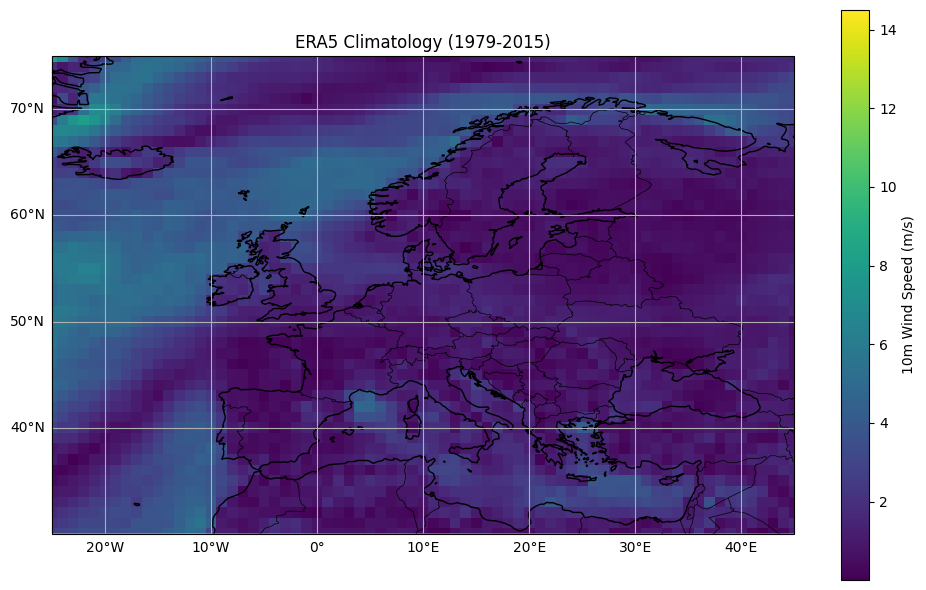

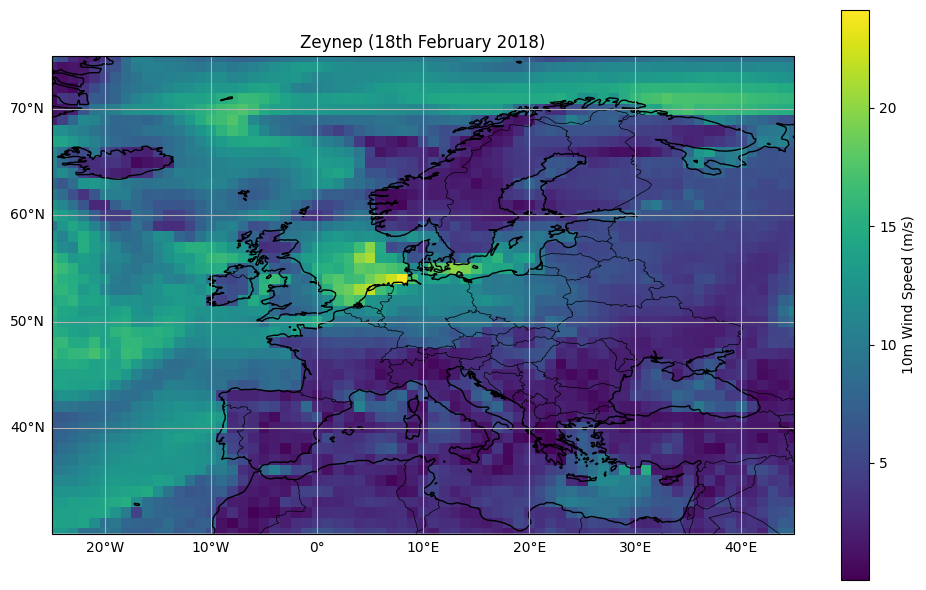

In [15]:
# atmospheric variables: geopotential, temperature, specific_humidity, vertical_velocity,
# u_component_of_wind, v_component_of_wind, wind_speed

# surface variables (level = None): 10m_wind_speed, 2m_temperature, 10m_u_component_of_wind,
# 10m_v_component_of_wind, total_precipitation_6hr, mean_sea_level_pressure

variable = "10m_wind_speed"
level = None  # None for surface variables, 13 for atmospheric variables


# 0 = 10:00 UTC, 1 = 16:00 UTC, 2 (or -1) = 22:00 UTC
time = -1

plot_variable(
    climatology,
    time=time,
    level=level,
    var_name=variable,
    title="ERA5 Climatology (1979-2015)",
)

plot_variable(
    zeynep,
    time=time,
    level=level,
    var_name=variable,
    title="Zeynep (18th February 2018)",
)